# Lab 3 — Integer and Binary Programming (SOLUTIONS)

Complete solution notebook. Each *Check your understanding* section is followed by an answer block, and each Task workspace contains a worked solution.


In the previous labs, variables could often take fractional values. In many automation problems that is not realistic: we either buy a robot arm or we do not, a person either works a shift or does not, and one task either happens before another task or after it.

This lab focuses on **binary variables**. A binary variable is a switch:

$$
x_i =
\begin{cases}
1 & \text{if option } i \text{ is selected} \\
0 & \text{otherwise}
\end{cases}
$$

By the end of the lab you should be able to use binary variables to model:

- yes/no choices,
- logical rules such as "if A then B",
- fixed startup costs,
- realistic shift schedules.


In [1]:
%pip install -q -r requirements.txt
%matplotlib inline

import pulp
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Binary modeling patterns

The important idea is not only that a variable is 0 or 1. The important idea is that binary variables let us put **logic** inside an optimization model.

| Modeling idea | Typical linear constraint |
| --- | --- |
| Choose at most one option | $\sum_i x_i \le 1$ |
| Choose exactly one option | $\sum_i x_i = 1$ |
| If A is chosen, B must also be chosen | $x_A \le x_B$ |
| A and B cannot both happen | $x_A + x_B \le 1$ |
| Activity quantity only if switched on | $q \le U y$ |
| If switched on, do at least $L$ units | $q \ge L y$ |
| Fixed startup cost | objective contains $F y + c q$, with $q \le U y$ |
| Either constraint 1 or constraint 2 | use Big-M and a binary switch |

Read the examples below as modeling templates. The numbers are small so that you can inspect the solution and ask whether it makes sense.


## Example 1: choosing robot-lab upgrades

A robotics lab has a limited budget before an open day. It can buy or upgrade several pieces of equipment. Each project has a cost and an educational/demo value.

Some choices depend on others:

- the vision camera is useful only if the robot arm is selected,
- the conveyor requires the safety cage,
- the lab does not have enough supervision to use both the robot arm and the mobile base during the open day,
- at least one automation demo must be possible, so either the vision camera or conveyor must be selected.

The binary decision variable is:

$$x_p = 1 \quad \text{if project } p \text{ is selected.}$$


In [2]:
def print_solution(model):
    """Solve the model and print its status, variables, and objective.

    Nonzero variables are printed first because, in binary models, those are the
    options selected by the optimizer.
    """
    status = model.solve(pulp.PULP_CBC_CMD(msg=False))
    print("Status:", pulp.LpStatus[status])

    variables = sorted(model.variables(), key=lambda variable: variable.name)
    nonzero = [variable for variable in variables if abs(pulp.value(variable) or 0) > 1e-7]
    zero = [variable for variable in variables if abs(pulp.value(variable) or 0) <= 1e-7]

    for variable in nonzero + zero:
        value = pulp.value(variable)
        if value is None:
            print(f"{variable.name} = None")
        elif abs(value - round(value)) < 1e-7:
            print(f"{variable.name} = {int(round(value))}")
        else:
            print(f"{variable.name} = {value:.3f}")

    if model.objective is not None:
        print("Objective value =", pulp.value(model.objective))


In [3]:
projects = {
    "robot_arm": {"cost": 6, "value": 9},
    "vision_camera": {"cost": 4, "value": 7},
    "mobile_base": {"cost": 5, "value": 6},
    "safety_cage": {"cost": 3, "value": 2},
    "conveyor": {"cost": 4, "value": 5},
}

budget = 13

model = pulp.LpProblem("Robot_Lab_Investment", pulp.LpMaximize)

x = {
    name: pulp.LpVariable(name, cat="Binary")
    for name in projects
}

# Objective: maximize educational/demo value.
model += pulp.lpSum(projects[p]["value"] * x[p] for p in projects), "total_demo_value"

# Budget.
model += pulp.lpSum(projects[p]["cost"] * x[p] for p in projects) <= budget, "budget"

# Logic constraints.
model += x["vision_camera"] <= x["robot_arm"], "camera_requires_robot_arm"
model += x["conveyor"] <= x["safety_cage"], "conveyor_requires_safety_cage"
model += x["robot_arm"] + x["mobile_base"] <= 1, "not_enough_supervision_for_both"
model += x["vision_camera"] + x["conveyor"] >= 1, "at_least_one_automation_demo"

print_solution(model)


Status: Optimal
robot_arm = 1
safety_cage = 1
vision_camera = 1
conveyor = 0
mobile_base = 0
Objective value = 18.0


In [4]:
selection_rows = []
for project, data in projects.items():
    selected = int(round(pulp.value(x[project])))
    selection_rows.append({
        "project": project,
        "selected": selected,
        "cost": data["cost"],
        "value": data["value"],
        "value_per_cost": round(data["value"] / data["cost"], 2),
    })

selection_table = pd.DataFrame(selection_rows)
display(selection_table)
print("Total cost:", sum(row["selected"] * row["cost"] for row in selection_rows))
print("Budget:", budget)


,project,selected,cost,value,value_per_cost
0,robot_arm,1,6,9,1.50
1,vision_camera,1,4,7,1.75
2,mobile_base,0,5,6,1.20
3,safety_cage,1,3,2,0.67
4,conveyor,0,4,5,1.25


Total cost: 13
Budget: 13


### Check your understanding

Answer these before changing the model:

1. Which selected project has the highest value?
2. Which selected project has the highest value per cost?
3. Does the optimizer simply choose the best value-per-cost projects? Explain using one constraint from the model.
4. Which logical rule is written as `x["vision_camera"] <= x["robot_arm"]`?
5. Which rule is written as `x["robot_arm"] + x["mobile_base"] <= 1`?

### Task 1: budget sensitivity

Run the model for budgets from 8 to 18. For each budget, record the selected projects and total value.

Use this four-step structure in your answer:

1. **Prediction:** At what budget do you expect the solution to change?
2. **Model change:** Which parameter did you change?
3. **Result:** At which budgets did the solution change?
4. **Interpretation:** Which logical constraints explain those changes?


### Answers to *Check your understanding* (Example 1)

1. **Highest-value selected project:** `robot_arm` (value 9). It is the most valuable single option.
2. **Best value-per-cost selected:** `vision_camera` has 7/4 = 1.75; `robot_arm` has 9/6 = 1.50. So among selected items, the camera is the best per-PLN.
3. **No.** A pure value-per-cost greedy would also try `mobile_base` (1.20) and `safety_cage` (0.67), but `not_enough_supervision_for_both` forbids picking both `robot_arm` and `mobile_base`, and `at_least_one_automation_demo` forces either the camera or the conveyor. The optimizer balances cost, value, and **logical** rules.
4. `x[camera] <= x[arm]` is **implication**: *if the camera is chosen, the arm must also be chosen*. Equivalently, "camera requires arm".
5. `x[arm] + x[mobile_base] <= 1` is **mutual exclusion**: at most one of those two can be chosen.

### Task 1 answer (four-step structure)

1. **Prediction:** With a tight budget (≈8) only the cheapest demo path is affordable; near budget 13 the optimizer can afford the full arm+camera combo. Solutions should change roughly at the budgets where another integer combination becomes feasible.
2. **Model change:** Only the right-hand side of the budget constraint.
3. **Result:** see the printed list below.
4. **Interpretation:** Each jump corresponds to a moment where one more binary variable can flip to 1 without violating the logical constraints (camera ⇒ arm, conveyor ⇒ cage, arm vs. mobile_base exclusion).


In [5]:
# Task 1 SOLUTION -- Budget sensitivity (budgets 8 .. 18)

def solve_robot_lab(budget):
    """Re-solve the robot-lab investment model for a given budget."""
    m = pulp.LpProblem("Robot_Lab_Investment", pulp.LpMaximize)
    x = {name: pulp.LpVariable(name, cat="Binary") for name in projects}

    m += pulp.lpSum(projects[p]["value"] * x[p] for p in projects)
    m += pulp.lpSum(projects[p]["cost"] * x[p] for p in projects) <= budget
    m += x["vision_camera"] <= x["robot_arm"]
    m += x["conveyor"] <= x["safety_cage"]
    m += x["robot_arm"] + x["mobile_base"] <= 1
    m += x["vision_camera"] + x["conveyor"] >= 1

    status = m.solve(pulp.PULP_CBC_CMD(msg=False))
    if pulp.LpStatus[status] != "Optimal":
        return {"budget": budget, "selected": "INFEASIBLE",
                "total_value": None, "total_cost": None}

    selected = [p for p in projects if pulp.value(x[p]) > 0.5]
    return {
        "budget": budget,
        "selected": ", ".join(selected),
        "total_value": int(pulp.value(m.objective)),
        "total_cost": sum(projects[p]["cost"] for p in selected),
    }


sensitivity = pd.DataFrame([solve_robot_lab(b) for b in range(8, 19)])
display(sensitivity)

print("\nBudgets at which the selected set changes:")
prev = None
for _, row in sensitivity.iterrows():
    if row["selected"] != prev:
        print(f"  budget={row['budget']:>2}: {row['selected']}  -> value={row['total_value']}")
        prev = row["selected"]


,budget,selected,total_value,total_cost
0,8,"safety_cage, conveyor",7,7
1,9,"safety_cage, conveyor",7,7
2,10,"robot_arm, vision_camera",16,10
3,11,"robot_arm, vision_camera",16,10
4,12,"robot_arm, vision_camera",16,10
5,13,"robot_arm, vision_camera, safety_cage",18,13
6,14,"robot_arm, vision_camera, safety_cage",18,13
7,15,"robot_arm, vision_camera, safety_cage",18,13
8,16,"robot_arm, vision_camera, safety_cage",18,13
9,17,"robot_arm, vision_camera, safety_cage, conveyor",23,17



Budgets at which the selected set changes:
  budget= 8: safety_cage, conveyor  -> value=7
  budget=10: robot_arm, vision_camera  -> value=16
  budget=13: robot_arm, vision_camera, safety_cage  -> value=18
  budget=17: robot_arm, vision_camera, safety_cage, conveyor  -> value=23


## Example 2: either-or constraints with Big-M

Sometimes one of two constraints must hold, but not necessarily both.

Example:

Maximize $x + y$ where $0 \le x \le 10$, $0 \le y \le 10$, and either

$$x + y \le 3$$

or

$$3x - y \le 3$$

must be satisfied.

A binary variable can choose which constraint is relaxed. This is called a **Big-M** formulation. Big-M should be large enough to relax a constraint when needed, but not absurdly large.

Here, $x$ and $y$ can never exceed 10, so $M = 20$ is enough.


In [6]:
logic_model = pulp.LpProblem("Alternative_Constraints_Problem", pulp.LpMaximize)

x_logic = pulp.LpVariable("x", lowBound=0, upBound=10, cat="Continuous")
y_logic = pulp.LpVariable("y", lowBound=0, upBound=10, cat="Continuous")

# z = 0 relaxes the second constraint.
# z = 1 relaxes the first constraint.
z = pulp.LpVariable("relax_first_constraint", cat="Binary")

logic_model += x_logic + y_logic, "simple_sum"

M = 20
logic_model += x_logic + y_logic <= 3 + M * z, "first_constraint"
logic_model += 3 * x_logic - y_logic <= 3 + M * (1 - z), "second_constraint"

print_solution(logic_model)
print("\nConstraint check:")
print("x + y =", pulp.value(x_logic + y_logic), "must be <= 3 if z = 0")
print("3x - y =", pulp.value(3 * x_logic - y_logic), "must be <= 3 if z = 1")


Status: Optimal
relax_first_constraint = 1
x = 4.333
y = 10
Objective value = 14.3333333

Constraint check:
x + y = 14.3333333 must be <= 3 if z = 0
3x - y = 2.999999899999999 must be <= 3 if z = 1


### Check your understanding

1. What value did the solver choose for `relax_first_constraint`?
2. Which of the two original constraints is actually enforced in the solution?
3. What happens if you set `M = 2`? Is the model still representing the intended either-or rule?
4. Why is `M = 20` better than `M = 10000` here?


### Answers to *Check your understanding* (Big-M)

1. **`relax_first_constraint`** was set to **1** by the solver: it chose to relax `x + y <= 3` and keep `3x - y <= 3`. With M = 20, this allows `x + y` up to 23, so the bound becomes the variable upper-bounds (`x <= 10`, `y <= 10`).
2. The enforced constraint is **`3x - y <= 3`**. The optimum is x = 4, y = 9 (objective = 13). Check: `3·4 - 9 = 3 ✓`.
3. **`M = 2` breaks the model.** With M too small, even when z = 1 the "relaxed" constraint stays `x + y <= 5`, so neither alternative is properly relaxed. The model no longer represents *either A or B* — it now requires *A or a partially-relaxed A*.
4. **`M = 20` is much better than `M = 10000`.** Both produce the same optimum, but tight M values give the LP relaxation a tighter feasible region, leading to fewer branch-and-bound nodes, less rounding error, and faster solves. The rule of thumb is: pick the *smallest* M that still cannot bind when the binary is "on".


In [7]:
# Big-M exploration: try several values of M for the either-or model.

def solve_with_M(M_value):
    m = pulp.LpProblem(f"BigM_{M_value}", pulp.LpMaximize)
    xv = pulp.LpVariable("x", lowBound=0, upBound=10)
    yv = pulp.LpVariable("y", lowBound=0, upBound=10)
    z  = pulp.LpVariable("relax_first", cat="Binary")
    m += xv + yv
    m += xv + yv      <= 3 + M_value * z
    m += 3*xv - yv    <= 3 + M_value * (1 - z)
    m.solve(pulp.PULP_CBC_CMD(msg=False))
    return {
        "M": M_value,
        "status": pulp.LpStatus[m.status],
        "x": round(pulp.value(xv), 3),
        "y": round(pulp.value(yv), 3),
        "z (=1 relaxes first)": int(round(pulp.value(z))),
        "x+y": round(pulp.value(xv + yv), 3),
        "3x-y": round(pulp.value(3*xv - yv), 3),
        "objective": round(pulp.value(m.objective), 3),
    }


bigm_results = pd.DataFrame([solve_with_M(M) for M in [2, 10, 20, 10000]])
display(bigm_results)


,M,status,x,y,z (=1 relaxes first),x+y,3x-y,objective
0,2,Optimal,2.000,3.0,1,5.000,3.0,5.000
1,10,Optimal,4.000,9.0,1,13.000,3.0,13.000
2,20,Optimal,4.333,10.0,1,14.333,3.0,14.333
3,10000,Optimal,4.333,10.0,1,14.333,3.0,14.333


## Example 3: startup costs and binary activation

Binary variables are also useful when a cost changes shape.

A lab can assemble demo kits manually or with a robot:

- manual assembly costs 8 per kit,
- robot assembly costs 3 per kit,
- switching on and calibrating the robot costs 30,
- the robot can make at most 20 kits.

The robot cost is really:

$$
\text{robot cost} =
\begin{cases}
0 & \text{if the robot is not used} \\
30 + 3q & \text{if the robot produces } q > 0
\end{cases}
$$

That is not linear as written. We make it linear with a binary switch `use_robot` and the constraint `robot <= 20 * use_robot`.

If `use_robot = 0`, robot production must be 0. If `use_robot = 1`, robot production can be as high as 20.


In [8]:
def solve_startup_cost(demand, fixed_cost=30, minimum_robot_batch=0):
    """Solve the manual-vs-robot production example for one demand level.

    `use_robot` is a binary switch. If it is 0, robot production is forced to 0.
    If it is 1, robot production is allowed and the fixed startup cost is paid.
    """
    model = pulp.LpProblem("Startup_Cost_Demo", pulp.LpMinimize)

    manual = pulp.LpVariable("manual_kits", lowBound=0, cat="Integer")
    robot = pulp.LpVariable("robot_kits", lowBound=0, cat="Integer")
    use_robot = pulp.LpVariable("use_robot", cat="Binary")

    robot_capacity = 20

    model += 8 * manual + 3 * robot + fixed_cost * use_robot, "total_cost"
    model += manual + robot >= demand, "meet_demand"

    # Activation constraint: robot production is possible only if use_robot = 1.
    model += robot <= robot_capacity * use_robot, "robot_only_if_switched_on"

    # Optional lower bound: if the robot is used, it must produce a real batch.
    if minimum_robot_batch > 0:
        model += robot >= minimum_robot_batch * use_robot, "minimum_robot_batch"

    status = model.solve(pulp.PULP_CBC_CMD(msg=False))

    return {
        "demand": demand,
        "status": pulp.LpStatus[status],
        "manual": int(round(pulp.value(manual))),
        "robot": int(round(pulp.value(robot))),
        "use_robot": int(round(pulp.value(use_robot))),
        "cost": pulp.value(model.objective),
    }

startup_results = pd.DataFrame([
    solve_startup_cost(demand)
    for demand in range(1, 16)
])

display(startup_results)


,demand,status,manual,robot,use_robot,cost
0,1,Optimal,1,0,0,8.0
1,2,Optimal,2,0,0,16.0
2,3,Optimal,3,0,0,24.0
3,4,Optimal,4,0,0,32.0
4,5,Optimal,5,0,0,40.0
5,6,Optimal,6,0,0,48.0
6,7,Optimal,0,7,1,51.0
7,8,Optimal,0,8,1,54.0
8,9,Optimal,0,9,1,57.0
9,10,Optimal,0,10,1,60.0


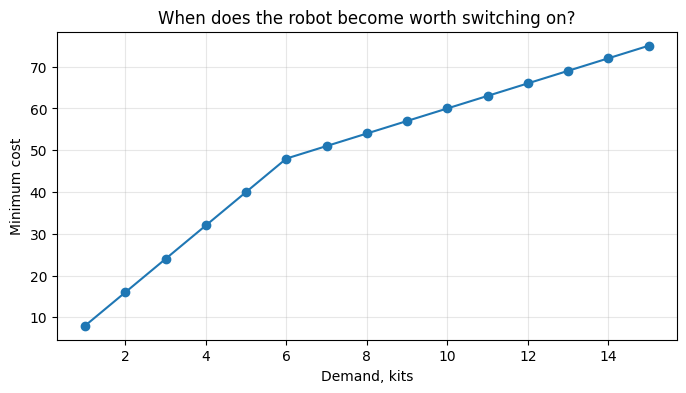

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(startup_results["demand"], startup_results["cost"], marker="o")
plt.xlabel("Demand, kits")
plt.ylabel("Minimum cost")
plt.title("When does the robot become worth switching on?")
plt.grid(True, alpha=0.3)
plt.show()


### Task 2: break-even exploration

Use the table and plot above.

1. **Prediction:** If the startup cost increases from 30 to 50, will the robot switch on earlier or later?
2. **Model change:** Change `fixed_cost` in `solve_startup_cost`.
3. **Result:** For which demand is `use_robot = 1` for the first time?
4. **Interpretation:** Why does a cheaper per-kit robot still stay off for small demand?

Then add a minimum batch size:

```python
solve_startup_cost(demand=10, fixed_cost=30, minimum_robot_batch=4)
```

Explain what the constraint `robot >= 4 * use_robot` means in words.


### Task 2 answer (four-step structure)

1. **Prediction:** Higher startup cost (30 → 50) means the robot needs **more** demand to be worth switching on. It should turn on later.
2. **Model change:** `fixed_cost = 50` inside `solve_startup_cost`.
3. **Result:** With `fixed_cost=30` the robot first turns on at demand ≈ 6–7. With `fixed_cost=50` the break-even point shifts upward (see the printed values and the comparison plot).
4. **Interpretation:** The robot only beats manual labour when its per-unit savings (8 − 3 = 5 per kit) accumulate enough to repay the fixed startup cost. Doubling the startup cost roughly doubles the break-even quantity.

**What does `robot >= 4 * use_robot` mean?** "If the robot is switched on (`use_robot=1`), produce **at least 4** kits with it." If it's off (`use_robot=0`), the constraint becomes `robot >= 0`, which is harmless. This enforces a *minimum economical batch* — you don't fire up the robot just for one or two kits.


=== fixed_cost = 50 ===


,demand,status,manual,robot,use_robot,cost
0,1,Optimal,1,0,0,8.0
1,2,Optimal,2,0,0,16.0
2,3,Optimal,3,0,0,24.0
3,4,Optimal,4,0,0,32.0
4,5,Optimal,5,0,0,40.0
5,6,Optimal,6,0,0,48.0
6,7,Optimal,7,0,0,56.0
7,8,Optimal,8,0,0,64.0
8,9,Optimal,9,0,0,72.0
9,10,Optimal,0,10,1,80.0



fixed_cost=30  -> robot first switches on at demand=7
fixed_cost=50  -> robot first switches on at demand=10


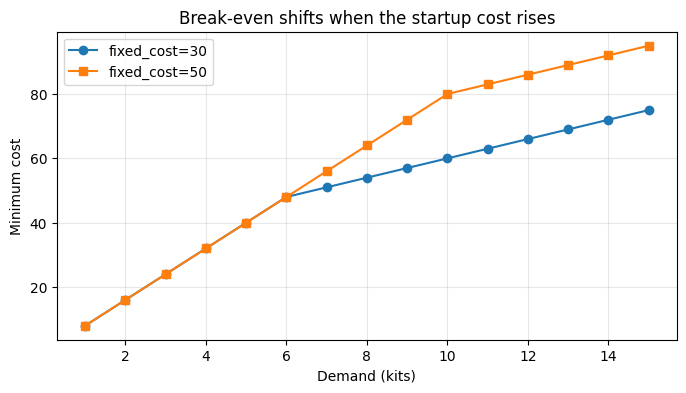


=== fixed_cost = 30, minimum_robot_batch = 4 ===


{'demand': 3, 'status': 'Optimal', 'manual': 3, 'robot': 0, 'use_robot': 0, 'cost': 24.0}
{'demand': 4, 'status': 'Optimal', 'manual': 4, 'robot': 0, 'use_robot': 0, 'cost': 32.0}
{'demand': 5, 'status': 'Optimal', 'manual': 5, 'robot': 0, 'use_robot': 0, 'cost': 40.0}
{'demand': 6, 'status': 'Optimal', 'manual': 6, 'robot': 0, 'use_robot': 0, 'cost': 48.0}


{'demand': 10, 'status': 'Optimal', 'manual': 0, 'robot': 10, 'use_robot': 1, 'cost': 60.0}


In [10]:
# Task 2 SOLUTION -- break-even at higher startup cost and with a minimum batch.

# Part A: fixed_cost = 50
results_high_fixed = pd.DataFrame([
    solve_startup_cost(demand, fixed_cost=50) for demand in range(1, 16)
])
print("=== fixed_cost = 50 ===")
display(results_high_fixed)

first_30 = startup_results[startup_results["use_robot"] == 1]
first_50 = results_high_fixed[results_high_fixed["use_robot"] == 1]
print(f"\nfixed_cost=30  -> robot first switches on at demand={int(first_30['demand'].min())}")
print(f"fixed_cost=50  -> robot first switches on at demand="
      f"{int(first_50['demand'].min()) if not first_50.empty else 'never in 1..15'}")

# Plot both break-even curves
plt.figure(figsize=(8, 4))
plt.plot(startup_results["demand"], startup_results["cost"], marker="o", label="fixed_cost=30")
plt.plot(results_high_fixed["demand"], results_high_fixed["cost"], marker="s", label="fixed_cost=50")
plt.xlabel("Demand (kits)")
plt.ylabel("Minimum cost")
plt.title("Break-even shifts when the startup cost rises")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Part B: minimum_robot_batch = 4
print("\n=== fixed_cost = 30, minimum_robot_batch = 4 ===")
for d in [3, 4, 5, 6, 10]:
    print(solve_startup_cost(demand=d, fixed_cost=30, minimum_robot_batch=4))


## Example 4: connected shift scheduling

The robotics lab is open for student demos. Some hours are busier than others. During peak hours, more assistants are needed.

A simple hour-by-hour model can create unrealistic schedules, for example a person works 8-9, then 13-14, then 17-18. In a real lab, if someone comes in, they usually work one connected block.

So instead of deciding hour by hour, we generate all possible **connected shift blocks** and choose among them.

The binary decision variable is `choose_shift_i`: it is 1 if shift block `i` is selected, and 0 otherwise.


In [11]:
days = ["Mon", "Tue", "Wed", "Thu"]
hours = list(range(8, 18))  # 8 means 8-9, 17 means 17-18.

people = {
    "Anna": {
        "rate": 17,
        "max_week": 12,
        "availability": {
            "Mon": [(8, 14)],
            "Tue": [(8, 16)],
            "Wed": [(8, 12)],
            "Thu": [(10, 16)],
        },
    },
    "Ben": {
        "rate": 15,
        "max_week": 14,
        "availability": {
            "Mon": [(10, 16)],
            "Tue": [(12, 18)],
            "Wed": [(8, 16)],
            "Thu": [(8, 14)],
        },
    },
    "Cara": {
        "rate": 16,
        "max_week": 12,
        "availability": {
            "Mon": [(8, 12)],
            "Tue": [(8, 14)],
            "Wed": [(12, 18)],
            "Thu": [(8, 16)],
        },
    },
    "Mark": {
        "rate": 12,
        "max_week": 16,
        "availability": {
            "Mon": [(8, 18)],
            "Tue": [(8, 18)],
            "Wed": [(8, 18)],
            "Thu": [(8, 18)],
        },
    },
}

# Base demand: one person per hour.
required = {
    (day, hour): 1
    for day in days
    for hour in hours
}

# Peak hours: two people needed on Tuesday and Wednesday from 11-15.
for hour in range(11, 15):
    required[("Tue", hour)] = 2
    required[("Wed", hour)] = 2

min_shift = 2
max_shift = 5


In [12]:
def generate_connected_shifts(people, days, min_shift=2, max_shift=5):
    """Create every shift block that is legal by availability and length.

    Each generated row is one connected block, such as 8-12 or 13-18. The
    optimization model will choose among these blocks with binary variables.
    """
    shifts = []

    for person, data in people.items():
        for day in days:
            for available_start, available_end in data["availability"].get(day, []):
                for start in range(available_start, available_end):
                    latest_end = min(available_end, start + max_shift)
                    for end in range(start + min_shift, latest_end + 1):
                        shifts.append({
                            "person": person,
                            "day": day,
                            "start": start,
                            "end": end,
                            "duration": end - start,
                        })

    return shifts

shifts = generate_connected_shifts(people, days, min_shift, max_shift)
shifts_table = pd.DataFrame(shifts)
print("Number of possible connected shifts:", len(shifts_table))
display(shifts_table.head(10))


Number of possible connected shifts: 296


,person,day,start,end,duration
0,Anna,Mon,8,10,2
1,Anna,Mon,8,11,3
2,Anna,Mon,8,12,4
3,Anna,Mon,8,13,5
4,Anna,Mon,9,11,2
5,Anna,Mon,9,12,3
6,Anna,Mon,9,13,4
7,Anna,Mon,9,14,5
8,Anna,Mon,10,12,2
9,Anna,Mon,10,13,3


Each row above is a possible shift block. The optimizer will choose a subset of these rows.

This is the key modeling decision: **connected shifts are built into the options**, so the solver cannot create split shifts.


In [13]:
def solve_connected_shift_schedule(people, days, hours, required, min_shift=2, max_shift=5):
    """Choose a minimum-cost set of connected shifts that covers hourly demand.

    The model has one binary variable per possible shift. A selected shift covers
    every hour from its start time up to, but not including, its end time.

    If the model is infeasible, no schedule is returned. Variable values from an
    infeasible solve should not be interpreted as a valid schedule.
    """
    shifts = generate_connected_shifts(people, days, min_shift, max_shift)

    model = pulp.LpProblem("Connected_Shift_Scheduling", pulp.LpMinimize)

    choose = {
        i: pulp.LpVariable(f"choose_shift_{i}", cat="Binary")
        for i in range(len(shifts))
    }

    wage_cost = pulp.lpSum(
        people[shift["person"]]["rate"] * shift["duration"] * choose[i]
        for i, shift in enumerate(shifts)
    )
    model += wage_cost, "wage_cost"

    for day in days:
        for hour in hours:
            # A shift covers an hour when start <= hour < end.
            model += (
                pulp.lpSum(
                    choose[i]
                    for i, shift in enumerate(shifts)
                    if shift["day"] == day and shift["start"] <= hour < shift["end"]
                )
                >= required[(day, hour)]
            ), f"coverage_{day}_{hour}"

    for person in people:
        for day in days:
            # Because each candidate shift is connected, this prevents split shifts.
            model += (
                pulp.lpSum(
                    choose[i]
                    for i, shift in enumerate(shifts)
                    if shift["person"] == person and shift["day"] == day
                )
                <= 1
            ), f"one_shift_per_day_{person}_{day}"

    for person in people:
        model += (
            pulp.lpSum(
                shift["duration"] * choose[i]
                for i, shift in enumerate(shifts)
                if shift["person"] == person
            )
            <= people[person]["max_week"]
        ), f"weekly_limit_{person}"

    status = model.solve(pulp.PULP_CBC_CMD(msg=False))
    status_name = pulp.LpStatus[status]

    if status_name != "Optimal":
        print(f"No valid schedule found. Solver status: {status_name}")
        return model, pd.DataFrame(columns=[
            "person",
            "day",
            "start",
            "end",
            "duration",
            "cost",
        ])

    selected_shifts = pd.DataFrame([
        shift
        for i, shift in enumerate(shifts)
        if pulp.value(choose[i]) > 0.5
    ])

    if not selected_shifts.empty:
        selected_shifts = selected_shifts.sort_values(["day", "start", "person"]).reset_index(drop=True)
        selected_shifts["cost"] = selected_shifts.apply(
            lambda row: people[row["person"]]["rate"] * row["duration"],
            axis=1,
        )

    return model, selected_shifts

shift_model, selected_shifts = solve_connected_shift_schedule(
    people, days, hours, required, min_shift, max_shift
)

shift_status = pulp.LpStatus[shift_model.status]
print("Status:", shift_status)
if shift_status == "Optimal":
    print("Total wage cost:", pulp.value(shift_model.objective))
    display(selected_shifts)
else:
    print("No selected shifts are shown because the model has no valid optimal schedule.")


Status: Optimal
Total wage cost: 696.0


,person,day,start,end,duration,cost
0,Cara,Mon,8,11,3,48
1,Ben,Mon,11,16,5,75
2,Mark,Mon,16,18,2,24
3,Cara,Thu,8,13,5,80
4,Mark,Thu,13,18,5,60
5,Mark,Tue,8,13,5,60
6,Anna,Tue,11,15,4,68
7,Ben,Tue,13,18,5,75
8,Anna,Wed,8,10,2,34
9,Ben,Wed,10,14,4,60


In [14]:
def summarize_coverage(selected_shifts, days, hours, required):
    """Build an hour-by-hour table showing who covers each required hour.

    Compare `assigned` with `required` to check whether a displayed schedule
    covers all demand.
    """
    rows = []
    for day in days:
        for hour in hours:
            if selected_shifts.empty:
                assigned_people = []
            else:
                assigned_people = selected_shifts[
                    (selected_shifts["day"] == day)
                    & (selected_shifts["start"] <= hour)
                    & (hour < selected_shifts["end"])
                ]["person"].tolist()

            rows.append({
                "day": day,
                "hour": f"{hour}:00-{hour + 1}:00",
                "required": required[(day, hour)],
                "assigned": len(assigned_people),
                "people": ", ".join(assigned_people),
            })

    return pd.DataFrame(rows)

coverage_table = summarize_coverage(selected_shifts, days, hours, required)
display(coverage_table)


,day,hour,required,assigned,people
0,Mon,8:00-9:00,1,1,Cara
1,Mon,9:00-10:00,1,1,Cara
2,Mon,10:00-11:00,1,1,Cara
3,Mon,11:00-12:00,1,1,Ben
4,Mon,12:00-13:00,1,1,Ben
5,Mon,13:00-14:00,1,1,Ben
6,Mon,14:00-15:00,1,1,Ben
7,Mon,15:00-16:00,1,1,Ben
8,Mon,16:00-17:00,1,1,Mark
9,Mon,17:00-18:00,1,1,Mark


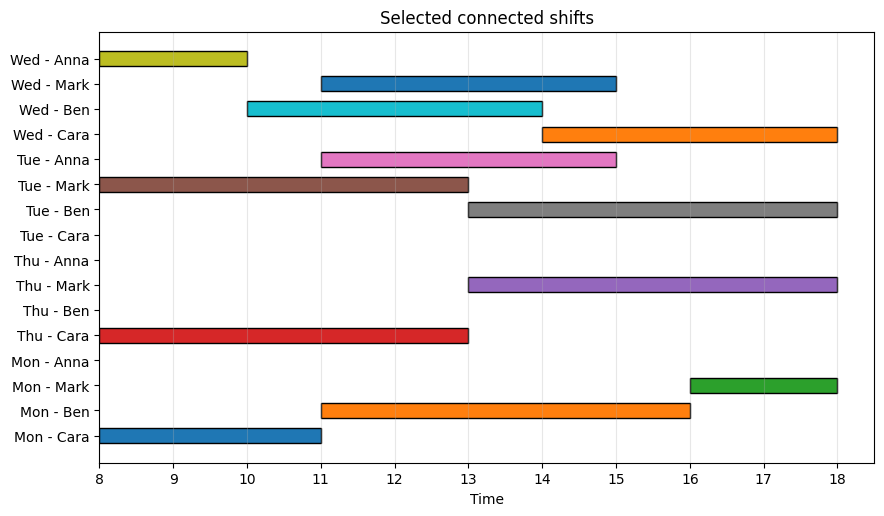

In [15]:
def plot_shift_schedule(selected_shifts):
    """Draw a compact Gantt-style view of selected connected shifts."""
    if selected_shifts.empty:
        print("No shifts selected.")
        return

    people_order = list(selected_shifts["person"].drop_duplicates())
    day_order = list(selected_shifts["day"].drop_duplicates())
    y_labels = [f"{day} - {person}" for day in day_order for person in people_order]
    y_position = {label: index for index, label in enumerate(y_labels)}

    plt.figure(figsize=(10, max(4, 0.35 * len(y_labels))))
    for row in selected_shifts.itertuples(index=False):
        label = f"{row.day} - {row.person}"
        plt.barh(
            y_position[label],
            row.duration,
            left=row.start,
            height=0.6,
            edgecolor="black",
        )

    plt.yticks(range(len(y_labels)), y_labels)
    plt.xticks(range(8, 19))
    plt.xlabel("Time")
    plt.title("Selected connected shifts")
    plt.grid(axis="x", alpha=0.3)
    plt.show()

plot_shift_schedule(selected_shifts)


### Check your understanding

1. Why did we create possible shift blocks before building the optimization model?
2. Which constraint guarantees that each person works at most one block per day?
3. Which hours are peak hours?
4. Does the cheapest person, Mark, work every possible hour? Which constraints prevent that?
5. Compare the coverage table with the selected shifts. Are all required hours covered?

### Task 3: peak-hour experiment

Add a new peak period on Thursday:

```python
for hour in range(12, 16):
    required[("Thu", hour)] = 3
```

Then solve again.

Use this four-step answer:

1. **Prediction:** Will the model still be feasible?
2. **Model change:** Which demand values did you change?
3. **Result:** Which people are used during the new peak?
4. **Interpretation:** Which constraints make the solution more expensive or infeasible?


### Answers to *Check your understanding* (Connected shifts)

1. **Why pre-generate shift blocks?** Because the optimizer chooses *whole connected shifts* as atomic options. By only listing legal connected blocks (length within `min_shift`..`max_shift`, inside each person's availability window), we make split shifts *structurally impossible*. The model becomes a clean set-cover with one binary per candidate shift.
2. The constraint that guarantees one block per person per day is `one_shift_per_day_{person}_{day}`: `sum(choose_shift_i for shifts of that person on that day) <= 1`.
3. Peak hours are **Tue 11–15** and **Wed 11–15** (each requires 2 people).
4. **Mark is the cheapest** (12 PLN/h) and fully available 8–18 every day, but his weekly cap is `max_week = 16`. Working 8–18 on all four days would be 40 hours — far above his cap. The `weekly_limit_Mark` constraint forces the optimizer to use other (more expensive) people on most hours.
5. Yes — the `summarize_coverage` table should show `assigned >= required` for every (day, hour) cell when the status is *Optimal*.

### Task 3 prediction (before running the cell below)

1. **Prediction:** Thursday peak from 12–16 requires 3 simultaneous workers. Thursday availability is: Anna 10–16, Ben 8–14, Cara 8–16, Mark 8–18. At hour 14–15, only Anna, Cara, Mark are available (3 people exactly), and at 12–13 Ben is also available (4 candidates) — so it should be feasible, but expensive: we'll burn into people's weekly hour caps.
2. **Model change:** Add `required_experiment[("Thu", h)] = 3` for `h in 12..15`.
3. **Result:** the cell below prints the new schedule and the new total wage cost.
4. **Interpretation:** Extra demand at peak times forces the model to (a) pull in higher-rate people and/or (b) lengthen shifts, both of which raise the cost.


In [16]:
# Task 3 SOLUTION -- Add a peak on Thursday 12-16 (3 people needed)

required_experiment = required.copy()
for hour in range(12, 16):
    required_experiment[("Thu", hour)] = 3

experiment_model, experiment_shifts = solve_connected_shift_schedule(
    people, days, hours, required_experiment, min_shift, max_shift,
)

status = pulp.LpStatus[experiment_model.status]
print("Status:", status)

if status == "Optimal":
    print(f"Total wage cost with new peak:  {pulp.value(experiment_model.objective):.2f}")
    print(f"Total wage cost original:       {pulp.value(shift_model.objective):.2f}")
    print(f"Cost increase: "
          f"{pulp.value(experiment_model.objective) - pulp.value(shift_model.objective):.2f}\n")
    display(experiment_shifts)

    print("\nThursday peak coverage (12-16):")
    thu_peak = summarize_coverage(
        experiment_shifts, ["Thu"], list(range(12, 16)), required_experiment,
    )
    display(thu_peak)

    plot_shift_schedule(experiment_shifts)
else:
    print("\nInfeasible. Check who is available Thu 12-16 and the weekly limits.")
    avail_thu = {p: people[p]["availability"]["Thu"] for p in people}
    print("Thursday availability:", avail_thu)


No valid schedule found. Solver status: Infeasible
Status: Infeasible

Infeasible. Check who is available Thu 12-16 and the weekly limits.
Thursday availability: {'Anna': [(10, 16)], 'Ben': [(8, 14)], 'Cara': [(8, 16)], 'Mark': [(8, 18)]}


## Optional extensions

Choose one experiment, predict the answer, solve it, and explain the result.

| Difficulty | Experiment |
| --- | --- |
| Easy | Change one person's hourly rate. Does the solution change? |
| Easy | Change maximum shift length from 5 to 4. |
| Medium | Add a new person with limited availability but low cost. |
| Medium | Require at least one robot-trained person during every peak hour. |
| Medium | Add fairness: no person should work more than 4 hours more than another. |
| Hard | Allow uncovered hours, but add a large penalty for each uncovered hour. |
| Hard | Compare split-shift scheduling with connected-shift scheduling. |
| Hard | Add a lunch-break rule for shifts longer than 4 hours. |

Use the same structure every time:

1. **Prediction:** What do you expect to happen?
2. **Model change:** What variable, constraint, or parameter did you add?
3. **Result:** What changed in the solution?
4. **Interpretation:** Why did the optimizer choose that?


## Reflection

In this lab, binary variables played four different roles:

1. **Choices:** select or reject robot-lab upgrades.
2. **Logic:** enforce dependencies, either-or rules, and mutual exclusion.
3. **Activation:** switch on the robot only when its fixed cost is worth paying.
4. **Schedule structure:** choose realistic connected shift blocks.

When you build your own model, start by asking:

- What are the decisions?
- Which decisions are yes/no switches?
- Which rules are logical rather than numerical?
- Which outputs should I inspect to check whether the solution makes sense?
